In [3]:
import pandas as pd

#Dünyaca ünlü endüstriyel makine sensör veri setinin doğrudan linki
url = "https://raw.githubusercontent.com/Asakharkar7/Predictive-Maintenance-Analysis/main/ai4i2020.csv"

#Veriyi internetten okuyup bir Pandas DataFrame'ine yüklüyoruz.
df = pd.read_csv(url)

#Verinin ilk 5 satırına göz atıyoruz
df.head()


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
#1- veri setini genel yapısı (kaç satır var, veri tipleri neler, boş veri var mı?)
print("--- VERİ SETİ GENEL BİLGİLER ---")
df.info()

#2- sayısal sütunların istatistiksel özeti(ort,min,max değerler)
print("\n--- İSTATİSTİKSEL ÖZET ---")
df.describe()

--- VERİ SETİ GENEL BİLGİLER ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


C:\Users\asyai\AppData\Local\Temp\ipykernel_15136\4056342675.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Machine failure', y='Torque [Nm]', data=df, palette="Set2")


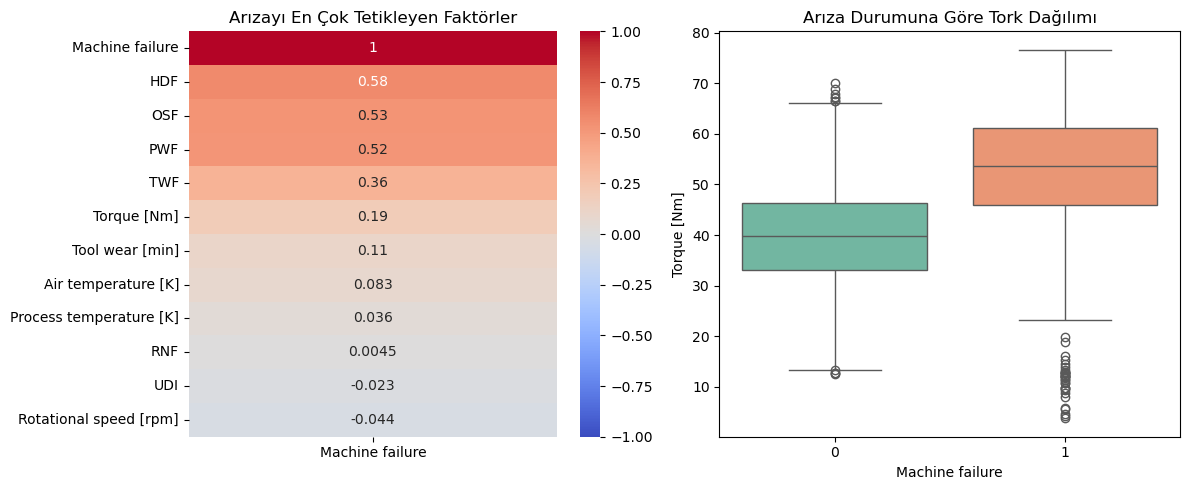

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grafiklerin düzgün gözükmesi için ayar
plt.figure(figsize=(12,5))

#1.Grafik: Hangi faktörler arızayı (mahcine failure) en çok tetikliyor? (korelasyon matrisi)
#Sadece sayısal sütunları seçiyoruz ki hata vermesin.
sayisal_df = df.select_dtypes(include=['int64','float64',])

plt.subplot(1,2,1)  #yan yana iki grafik çizilecek. birincisi bu.
sns.heatmap(sayisal_df.corr()[['Machine failure']].sort_values(by='Machine failure', ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Arızayı En Çok Tetikleyen Faktörler")

#2. Grafik: Tork Gücü ve Arıza İlişkisi (Kutu Grafiği - Boxplot)
plt.subplot(1,2,2) #Bu da ikinci grafik
sns.boxplot(x='Machine failure', y='Torque [Nm]', data=df, palette="Set2")
plt.title("Arıza Durumuna Göre Tork Dağılımı")

#Grafikleri ekrana sığdır ve göster
plt.tight_layout()
plt.show()


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

#1. Adım: Girdi(X) ve Hedef Çıktı (y) Değişkenlerini Ayıralım.
#Sadece ham sensör verilerini girdi yapıyoruz.
X = df[['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']]
y = df['Machine failure']  #tahmin etmek istediğimiz hedef

#2. Adım: Veriyi Eğitim ve Test Seti Olarak Bölelim.
#%80 eğitim, %20 test olacak şekilde ayırıyoruz.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Eğitim için ayrılan veri sayısı: {X_train.shape[0]} satır")
print(f"Test için ayrılan veri sayısı: {X_test.shape[0]} satır\n")

#3.Adım: Yapay Zeka Modelini Oluşturma ve Eğitme
#Endüstride bu tarz kararlarda çok başarılı olan 'Random Forest' algoritmasını seçiyoruz.
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train) #eğitimi başlatır fit eder

#4. Adım: Modeli Test Eme
y_pred = model.predict(X_test)

#5. Adım: Başarı Sonuçlarını Ekrana Yazdırma
print("--- MODEL  BAŞARI  RAPORU ---")
print(classification_report(y_test,y_pred))

Eğitim için ayrılan veri sayısı: 8000 satır
Test için ayrılan veri sayısı: 2000 satır

--- MODEL  BAŞARI  RAPORU ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.90      0.63      0.74        68

    accuracy                           0.98      2000
   macro avg       0.94      0.81      0.87      2000
weighted avg       0.98      0.98      0.98      2000



--- YENİ (DENGELENMİŞ)  MODEL BAŞARI RAPORU ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.89      0.57      0.70        68

    accuracy                           0.98      2000
   macro avg       0.94      0.79      0.84      2000
weighted avg       0.98      0.98      0.98      2000



<function matplotlib.pyplot.show(close=None, block=None)>

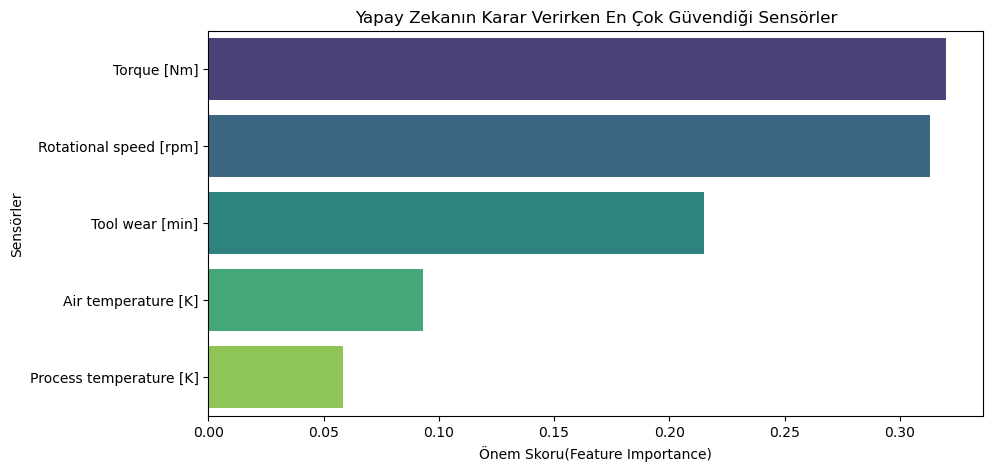

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

#1.Adım: Dengesizliği çözmek için 'class_weight="balanced"' parametresini ekliyoruz.
#Bu komut, yapay zekaya 'Arızalı (1) örnekleri gördüğünde hata yaparsan seni daha çok cezalandırırım' der.
gelismis_model = RandomForestClassifier(random_state=42, class_weight='balanced')
gelismis_model.fit(X_train, y_train)

#Yeni modeli test edelim.
y_pred_yeni = gelismis_model.predict(X_test)

print("--- YENİ (DENGELENMİŞ)  MODEL BAŞARI RAPORU ---")
print(classification_report(y_test,y_pred_yeni))

#2.Adım: Yapay Zekanın En Çok Önem Verdiği Sensörleri Görselleştirme
importances = gelismis_model.feature_importances_
features = X.columns

#Kolonları önem sırasına göre dizelim
indices = np.argsort(importances)[::-1] #tüm satırlar , son sütun hariç tüm sütunlar

plt.figure(figsize=(10,5))
sns.barplot(x=importances[indices], y=features[indices], hue=features[indices], palette="viridis", legend=False)
plt.title("Yapay Zekanın Karar Verirken En Çok Güvendiği Sensörler")
plt.xlabel("Önem Skoru(Feature Importance)")
plt.ylabel("Sensörler")
plt.show

In [17]:
#1. Adım: Modelden direkt 0 veya 1 tahmin etmesini değil, olasılıkları hesaplamasını istiyoruz
#predict_proba bize her makine için [Sağlam Olma İhtimali,Arızalı Olma İhtimali] şeklinde iki değer verir
olasiliklar = gelismis_model.predict_proba(X_test)[:,1] #sadece arıza olma (1) ihtimallerini alıyoruz.

#2. Adım: Alarm sınırını (Threshold) 0.50'den 0.20'ye düşürüyoruz
#Yani bozulma ihtimali %20'yi geçen her makineyi "Arıza Yapacak" olarak kabul et diyoruz.
y_pred_ozel_esik = (olasiliklar >= 0.20).astype(int)

print("--- SENSÖR ALARM HASSASİYETİ AYARLANMIŞ RAPOR (Eşik: 0.20) ---")
print(classification_report(y_test,y_pred_ozel_esik))

--- SENSÖR ALARM HASSASİYETİ AYARLANMIŞ RAPOR (Eşik: 0.20) ---
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.57      0.81      0.67        68

    accuracy                           0.97      2000
   macro avg       0.78      0.89      0.83      2000
weighted avg       0.98      0.97      0.97      2000

